In [1]:
# --- DATA LOADING + CLEANING (ALL-IN-ONE) ---
# Goal: Prepare clean dataset for analysis and modeling

import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("hotel_bookings.csv")

# Drop high-missing / low-value columns
df = df.drop(columns=['company'])

# Handle missing values
df['agent'] = df['agent'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['children'] = df['children'].fillna(0)

# Create readable target label for visuals
df['cancellation_status'] = df['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})

# Final check
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,cancellation_status
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,Not Canceled
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,Not Canceled
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,Not Canceled
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,Not Canceled
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03,Not Canceled


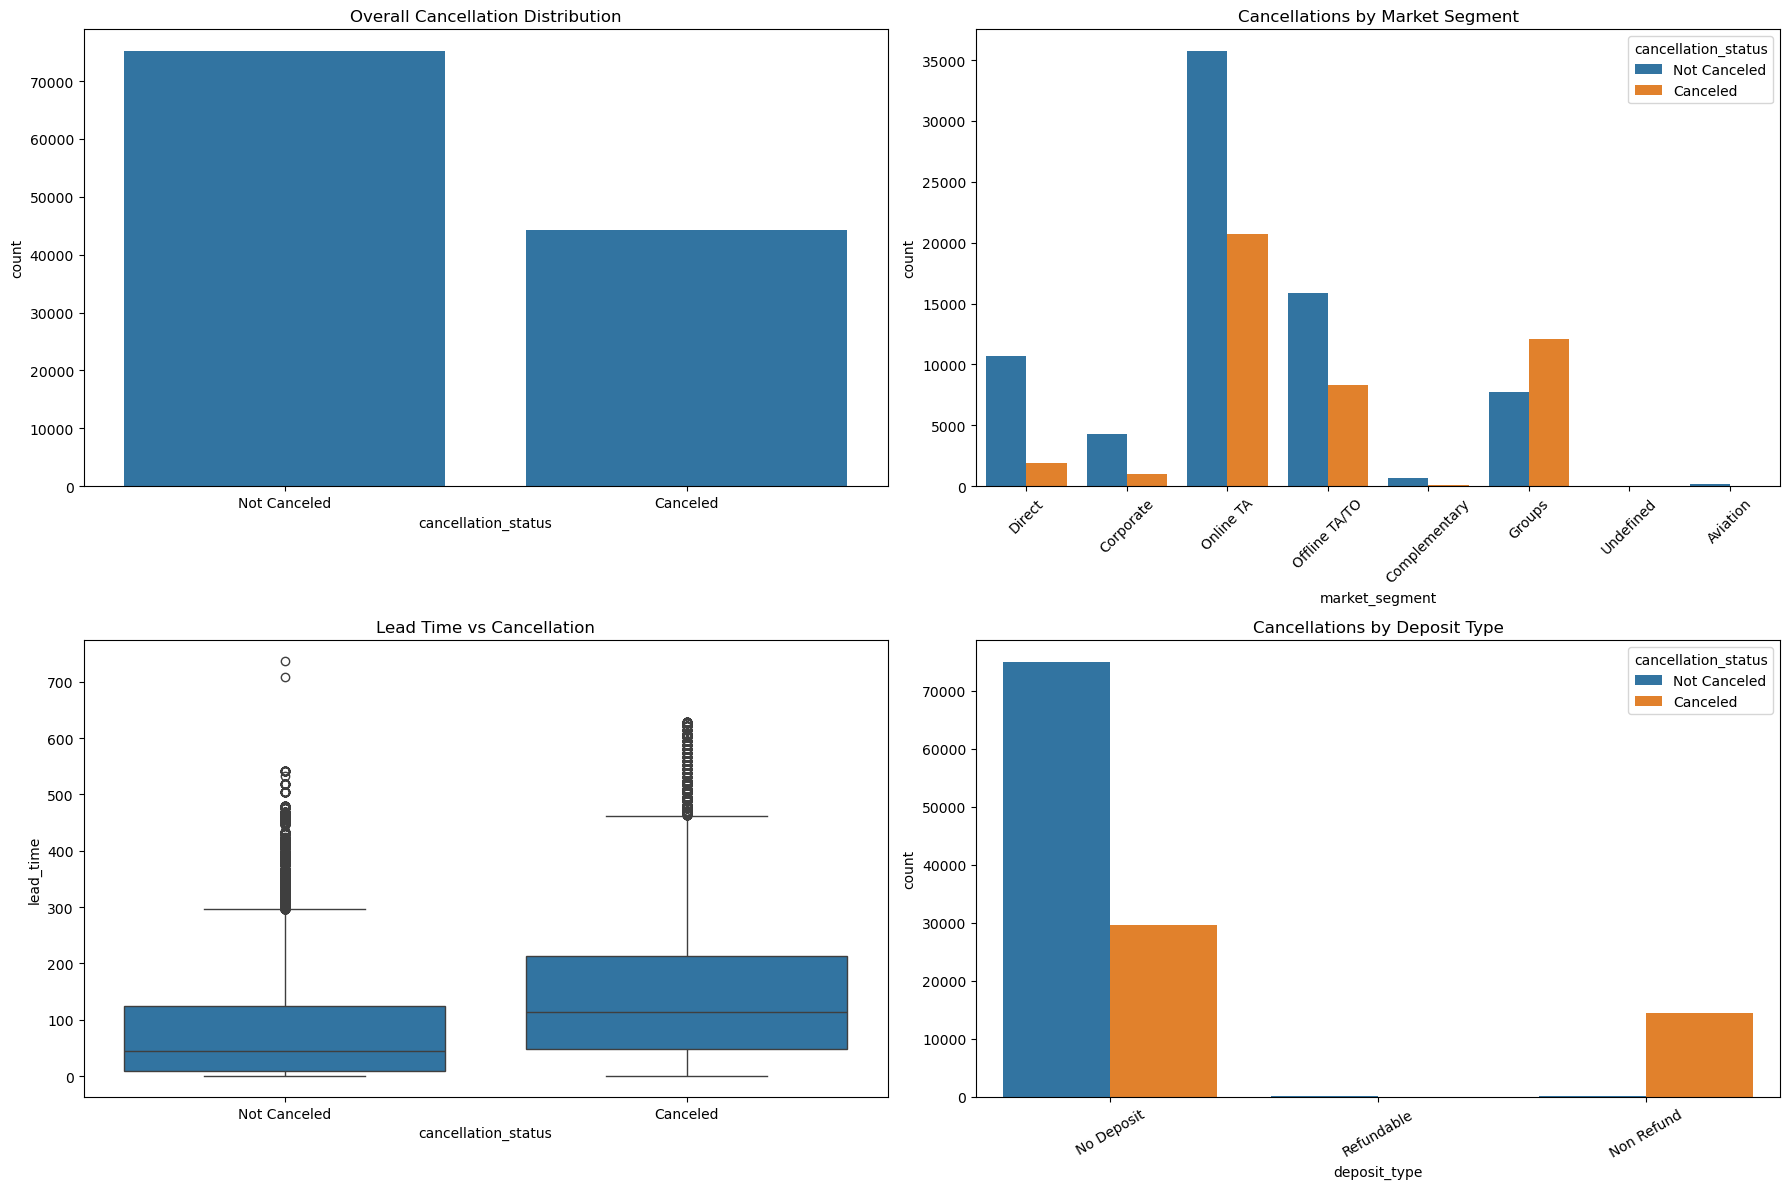

In [2]:
# --- KEY BUSINESS VISUALS ---
# Goal: Clearly show cancellation problem and main drivers

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 12))

# 1. Overall cancellations
plt.subplot(2, 2, 1)
sns.countplot(x='cancellation_status', data=df)
plt.title('Overall Cancellation Distribution')

# 2. Market segment (booking type)
plt.subplot(2, 2, 2)
sns.countplot(x='market_segment', hue='cancellation_status', data=df)
plt.title('Cancellations by Market Segment')
plt.xticks(rotation=45)

# 3. Lead time vs cancellation
plt.subplot(2, 2, 3)
sns.boxplot(x='cancellation_status', y='lead_time', data=df)
plt.title('Lead Time vs Cancellation')

# 4. Deposit type vs cancellation
plt.subplot(2, 2, 4)
sns.countplot(x='deposit_type', hue='cancellation_status', data=df)
plt.title('Cancellations by Deposit Type')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

<h3>Story</h3>

<p>
The analysis shows that <b>booking cancellations are a major revenue problem</b>, with roughly 
<span style="color:red; font-weight:bold;">37% of all bookings canceled</span>.
</p>

<p>
Among all customer segments, <b>Online TA</b> is the most important segment to watch. It does 
<b>not</b> have the highest cancellation rate, but it represents the 
<span style="color:green; font-weight:bold;">largest booking volume and one of the highest average daily rates</span>, 
which means it drives the <span style="color:red; font-weight:bold;">largest total revenue loss</span>.
</p>

<p>
The <b>Groups</b> segment is even riskier from a behavior standpoint, with a 
<span style="color:red; font-weight:bold;">very high cancellation rate (over 60%)</span>, 
making it one of the least reliable customer types.
</p>

<p>
The data also shows that customers with <b>longer lead times</b> and 
<b>no-deposit bookings</b> are much more likely to cancel, giving the business a clear set of early warning signals.
</p>

<h3>Why Use Machine Learning?</h3>

<p>
Instead of reacting after cancellations happen, the next step is to build a 
<b>machine learning model</b> that predicts whether a booking is likely to cancel 
before the stay date.
</p>

<p>
This allows the hotel to take a very specific action:
<span style="color:blue; font-weight:bold;">apply stricter deposit requirements only to bookings flagged as high-risk</span>.
</p>

<p>
Using the model, we can estimate how many cancellations could be prevented and 
<span style="color:green; font-weight:bold;">predict how much revenue could be saved if this strategy is implemented</span>.
</p>

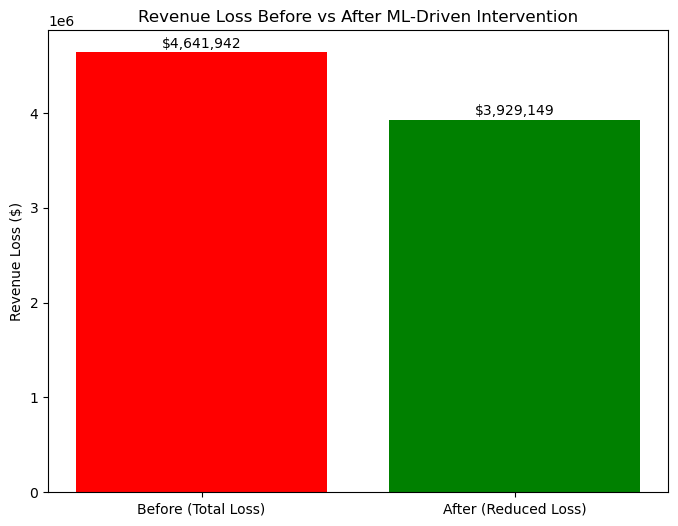

Revenue Recovered: $712793.55


In [4]:
# --- SIMPLE ML MODEL + BUSINESS IMPACT VISUALIZATION ---
# Goal: Predict cancellations + show revenue saved after intervention

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# --- Model (simple, no overkill) ---
features = [
    'lead_time', 'adr', 'deposit_type', 'market_segment',
    'customer_type', 'total_of_special_requests'
]

df_model = df[features + ['is_canceled']].copy()
df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop('is_canceled', axis=1)
y = df_model['is_canceled']

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# --- Predict probabilities ---
probs = model.predict_proba(X)[:, 1]
df['cancel_prob'] = probs

# --- Identify high-risk bookings (top 20%) ---
threshold = np.percentile(probs, 80)
high_risk = df['cancel_prob'] >= threshold

# --- Simulate intervention (reduce 30% of cancellations in high-risk group) ---
mask = (high_risk) & (df['is_canceled'] == 1)
recover_idx = df[mask].sample(frac=0.3, random_state=42).index

# --- Revenue calculations ---
total_loss = df[df['is_canceled'] == 1]['adr'].sum()
recovered = df.loc[recover_idx, 'adr'].sum()
new_loss = total_loss - recovered

# --- Plot: Before vs After ---
labels = ['Before (Total Loss)', 'After (Reduced Loss)']
values = [total_loss, new_loss]
colors = ['red', 'green']

plt.figure(figsize=(8,6))
plt.bar(labels, values, color=colors)
plt.title('Revenue Loss Before vs After ML-Driven Intervention')
plt.ylabel('Revenue Loss ($)')

# Add labels on bars
for i, v in enumerate(values):
    plt.text(i, v + 50000, f"${int(v):,}", ha='center')

plt.show()

print(f"Revenue Recovered: ${round(recovered,2)}")

<h1 style="font-size:32px; color:#2c3e50;">
🚀 Final Business Impact & Strategic Recommendation
</h1>

<p style="font-size:18px;">
By leveraging machine learning to identify high-risk bookings and applying targeted policy changes, 
the hotel can recover approximately 
<span style="color:green; font-weight:bold; font-size:22px;">
$712,793+
</span> 
in lost revenue.
</p>

<hr>

<h2 style="color:#34495e;">🎯 Key Actions</h2>

<ul style="font-size:18px;">
  <li>
    Apply 
    <span style="color:red; font-weight:bold;">non-refundable or partial deposits</span> 
    to <b>Online TA</b> and <b>Groups</b> bookings
  </li>
  <li>
    Introduce 
    <span style="color:red; font-weight:bold;">refund friction</span> 
    specifically for these high-risk segments
  </li>
  <li>
    Add a 
    <span style="color:blue; font-weight:bold;">“Change Booking Date”</span> 
    option directly on the cancellation page to retain customers
  </li>
</ul>

<hr>

<h2 style="color:#34495e;">💡 Why This Works</h2>

<ul style="font-size:18px;">
  <li><b>Online TA</b> → Highest volume + high revenue → largest total loss</li>
  <li><b>Groups</b> → Extremely high cancellation rate → unreliable segment</li>
  <li>Long lead times + flexible policies → increased cancellation behavior</li>
</ul>

<hr>

<h2 style="color:#34495e;">📈 Shareholder Value</h2>

<p style="font-size:18px;">
Implementing these targeted strategies will:
</p>

<ul style="font-size:18px;">
  <li>
    <span style="color:green; font-weight:bold;">Reduce cancellations at scale</span>
  </li>
  <li>
    <span style="color:green; font-weight:bold;">Increase realized revenue</span>
  </li>
  <li>
    <span style="color:green; font-weight:bold;">Improve forecasting accuracy</span>
  </li>
  <li>
    <span style="color:green; font-weight:bold;">Retain customers who would otherwise cancel</span>
  </li>
</ul>

<hr>

<p style="font-size:20px; font-weight:bold; color:#2c3e50;">
👉 If implemented, this strategy directly converts high-risk bookings into confirmed revenue.
</p>